In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

notebooks_folder = Path.cwd()
processed_folder = notebooks_folder.parent / "data" / "processed"
raw_folder = notebooks_folder.parent / "data" / "raw"

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

<Figure size 1200x600 with 0 Axes>

In [2]:
fund_master = pd.read_csv(processed_folder / "fund_master_cleaned.csv")
nav = pd.read_csv(processed_folder / "nav_history_cleaned.csv")
aum = pd.read_csv(processed_folder / "aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(processed_folder / "monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(processed_folder / "category_inflows_cleaned.csv")
investor = pd.read_csv(processed_folder / "investor_transactions_cleaned.csv")
folio = pd.read_csv(processed_folder / "industry_folio_count_cleaned.csv")
portfolio = pd.read_csv(processed_folder / "portfolio_holdings_cleaned.csv")
performance = pd.read_csv(processed_folder / "scheme_performance_cleaned.csv")


In [3]:
nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
folio["month"] = pd.to_datetime(folio["month"])
sip["month"] = pd.to_datetime(sip["month"])
category["month"] = pd.to_datetime(category["month"])
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color='amfi_code',
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Correction"
)

fig.show()


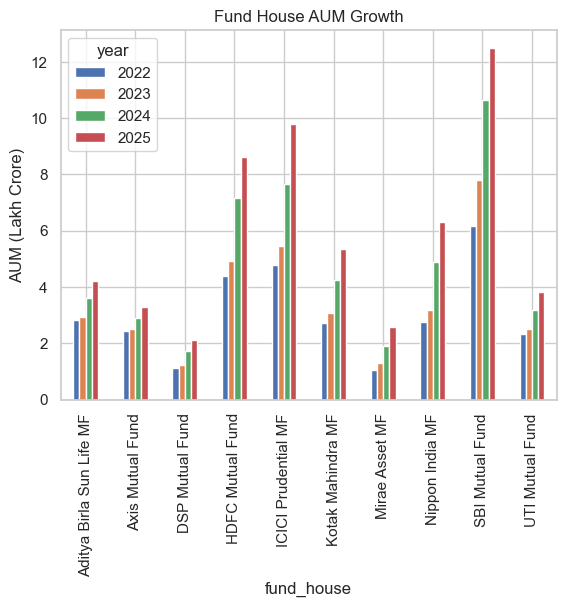

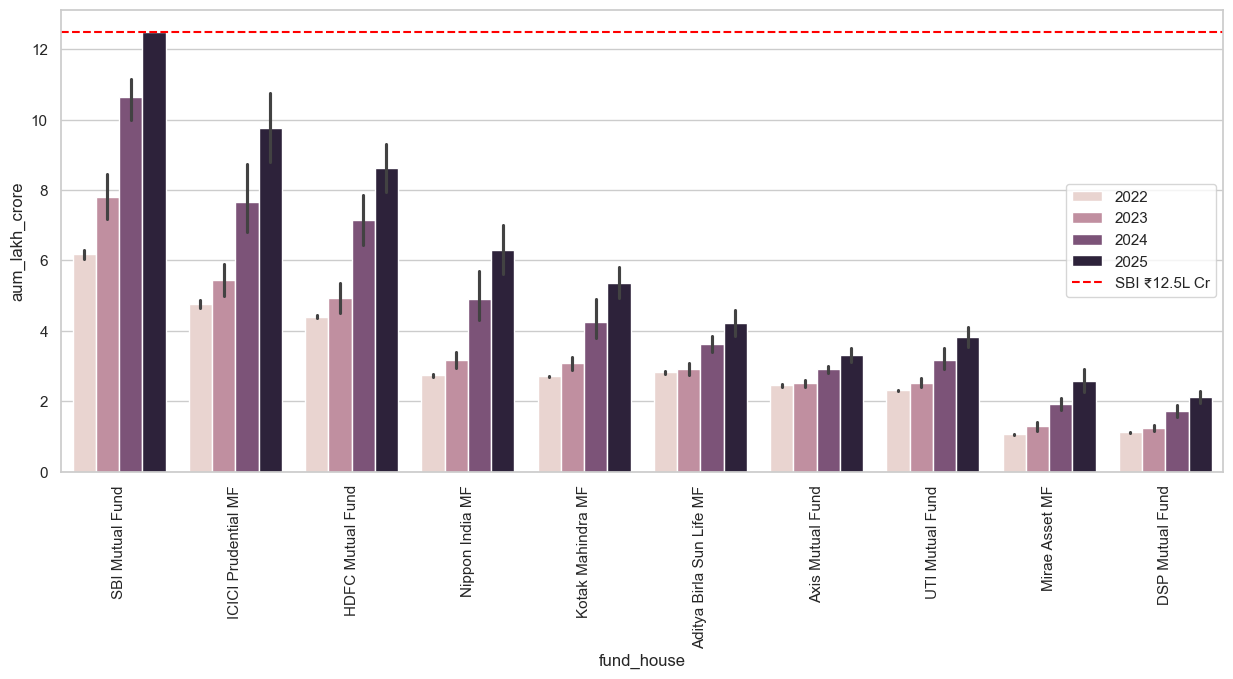

In [4]:
aum["year"] = aum["date"].dt.year

pivot = aum.pivot_table(
    index="fund_house",
    columns="year",
    values="aum_lakh_crore"
)

pivot.plot(kind="bar")

plt.title("Fund House AUM Growth")
plt.ylabel("AUM (Lakh Crore)")
plt.show()

plt.figure(figsize=(15,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)

plt.axhline(
    12.5,
    color="red",
    linestyle="--",
    label="SBI ₹12.5L Cr"
)

plt.legend()

plt.show()

In [5]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="₹31,002 Cr High",
    showarrow=True
)

fig.show()


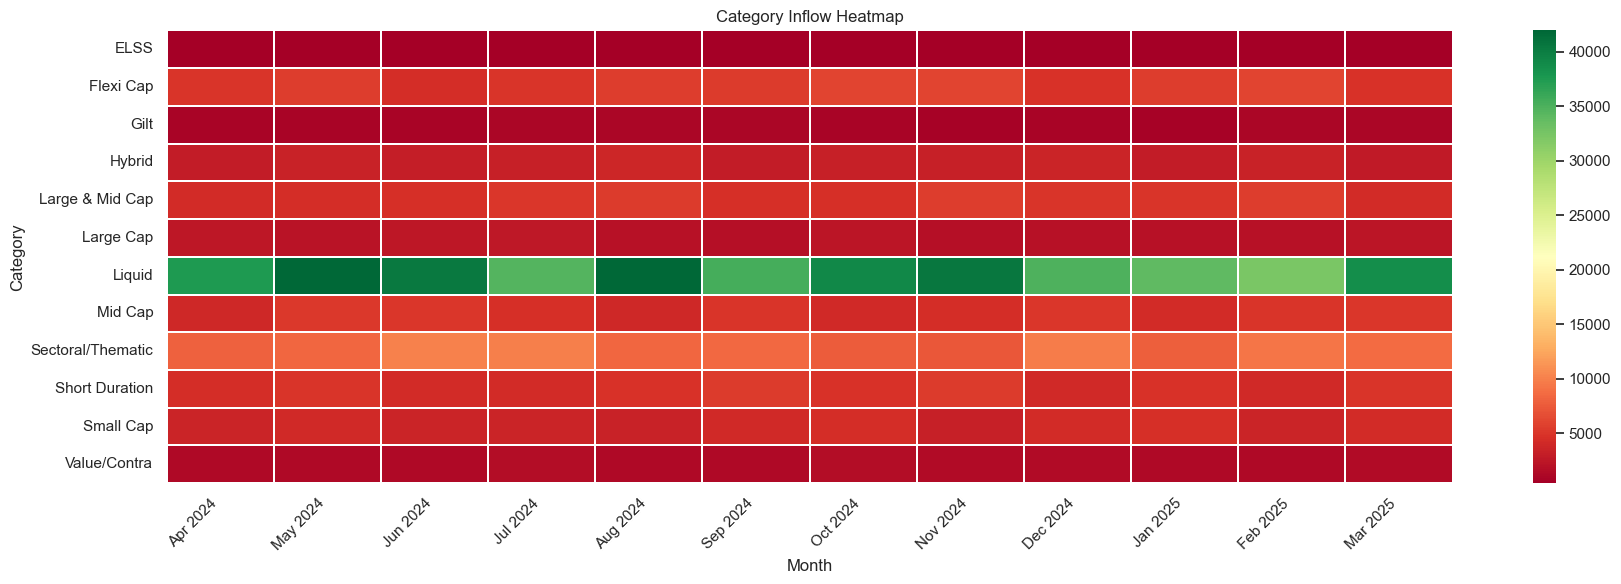

In [6]:
category["month_label"] = category["month"].dt.strftime("%b %Y")

heat = category.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

month_order = (
    category[["month", "month_label"]]
    .drop_duplicates()
    .sort_values("month")["month_label"]
)

heat = heat.reindex(columns=month_order)

plt.figure(figsize=(18, 6))

sns.heatmap(
    heat,
    cmap="RdYlGn",
    linewidths=0.2
)

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

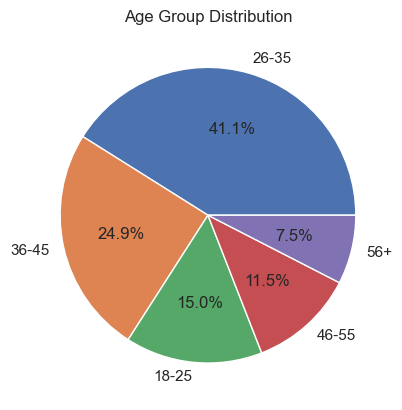

In [7]:
investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.ylabel("")

plt.show()

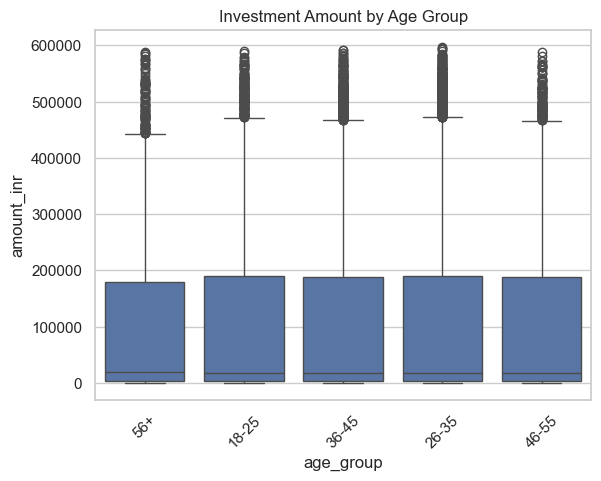

In [8]:
sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.title("Investment Amount by Age Group")

plt.show()

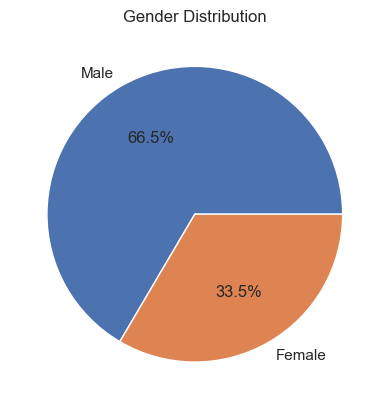

In [9]:
investor["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

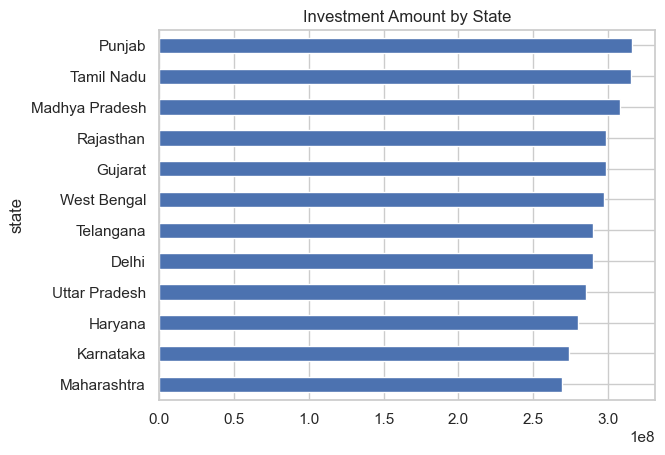

In [10]:
state = investor.groupby("state")["amount_inr"].sum().sort_values()

state.plot(kind="barh")

plt.title("Investment Amount by State")

plt.show()

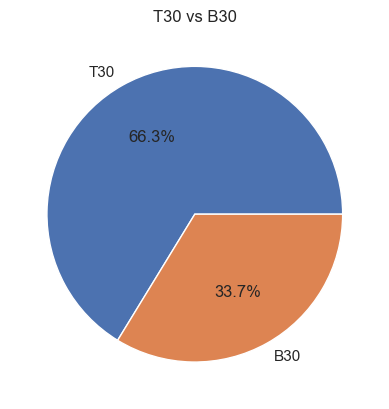

In [11]:
investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30")

plt.ylabel("")

plt.show()

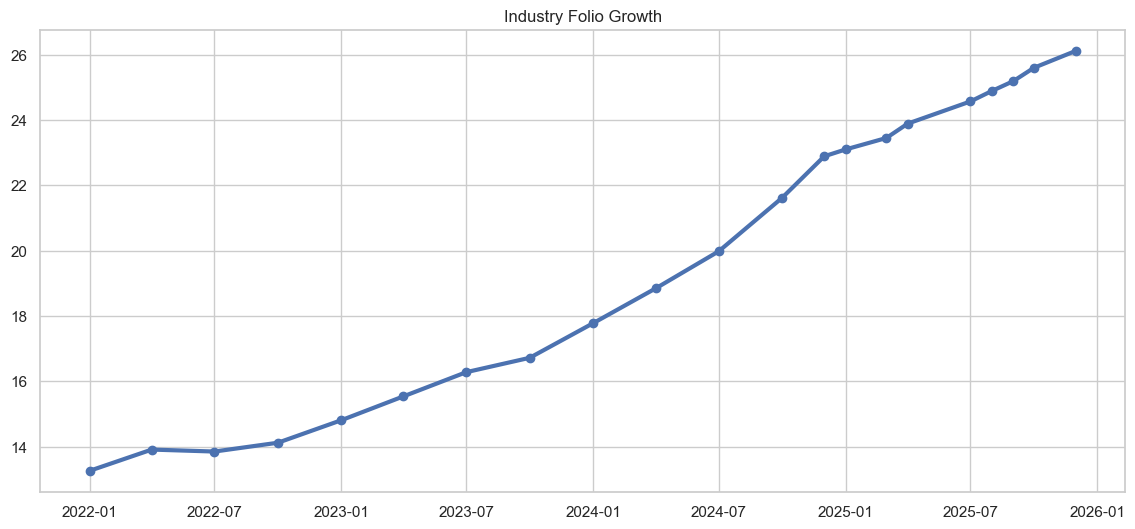

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=3
)

plt.scatter(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.show()

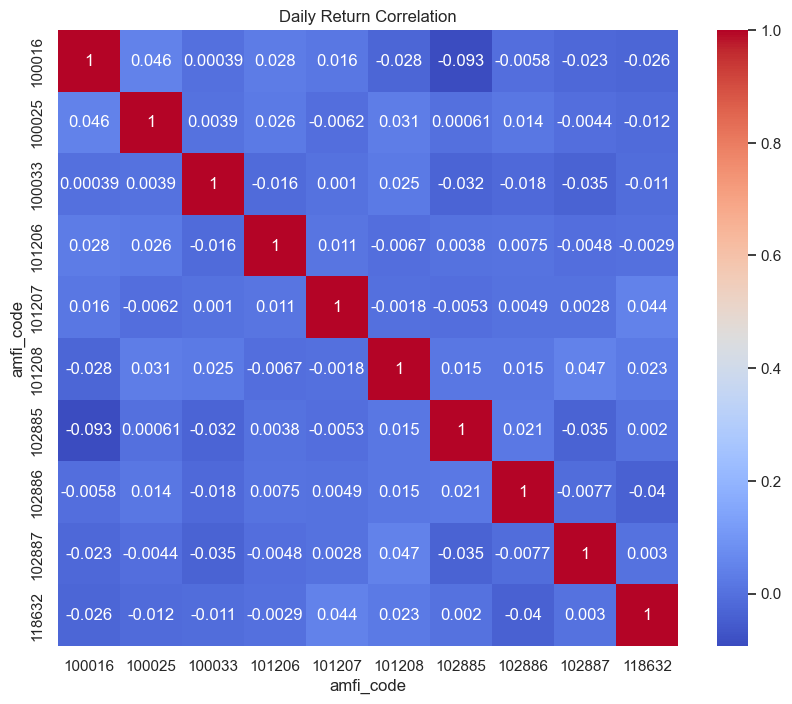

In [13]:

selected = nav["amfi_code"].unique()[:10]

corr = nav[
    nav["amfi_code"].isin(selected)
]

pivot = corr.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Daily Return Correlation")

plt.show()


In [14]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

fig = go.Figure(
    go.Pie(
        labels=sector.index,
        values=sector.values,
        hole=0.5
    )
)

fig.update_layout(
    title="Sector Allocation"
)

fig.show()

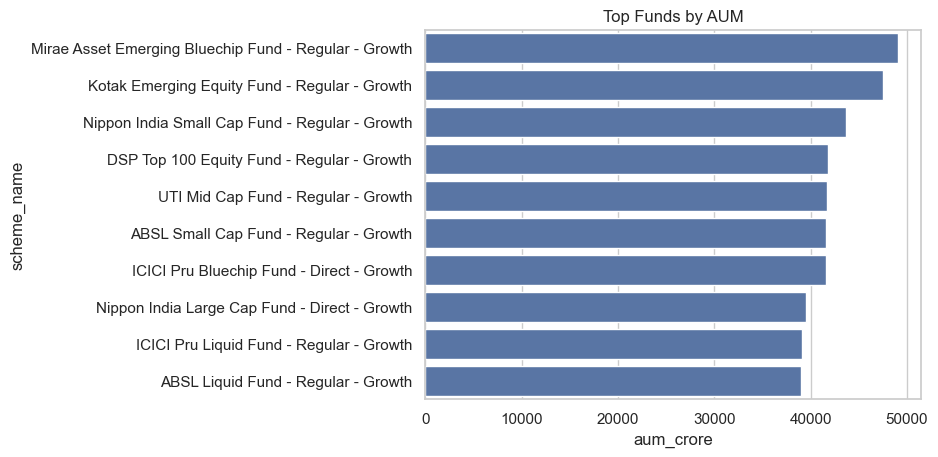

In [15]:
top = performance.nlargest(
    10,
    "aum_crore"
)

sns.barplot(
    data=top,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top Funds by AUM")

plt.show()

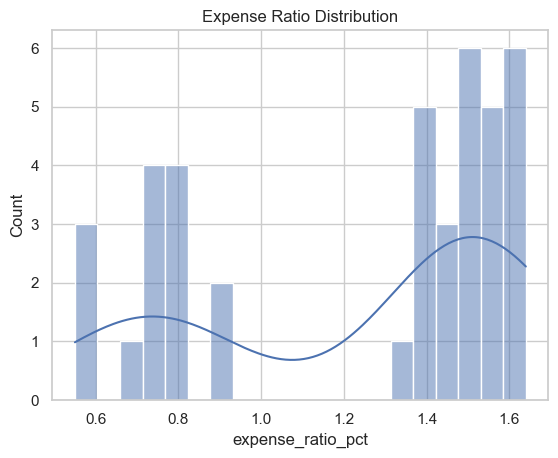

In [16]:
sns.histplot(
    performance["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

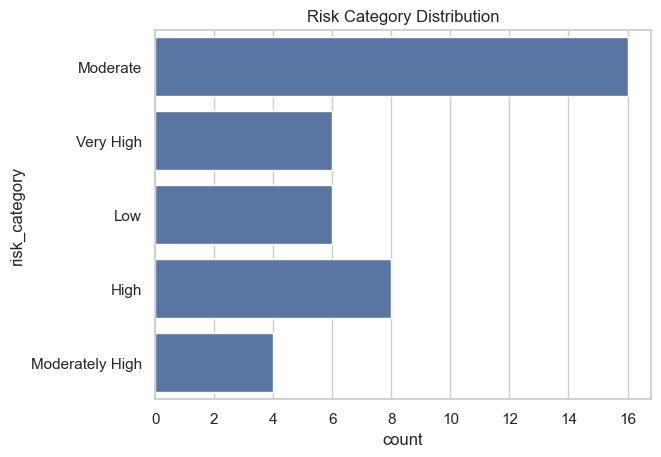

In [17]:
sns.countplot(
    data=fund_master,
    y="risk_category"
)

plt.title("Risk Category Distribution")

plt.show()

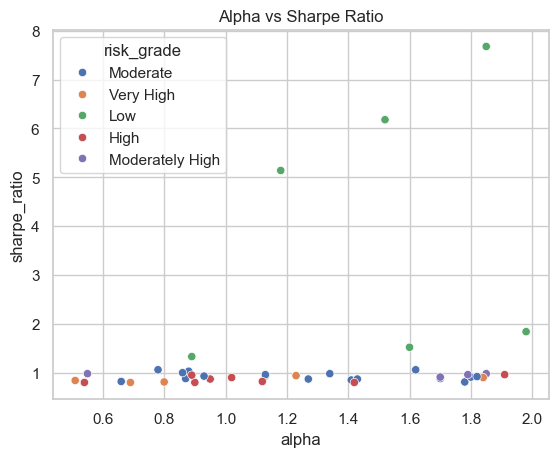

In [18]:
sns.scatterplot(
    data=performance,
    x="alpha",
    y="sharpe_ratio",
    hue="risk_grade"
)

plt.title("Alpha vs Sharpe Ratio")

plt.show()

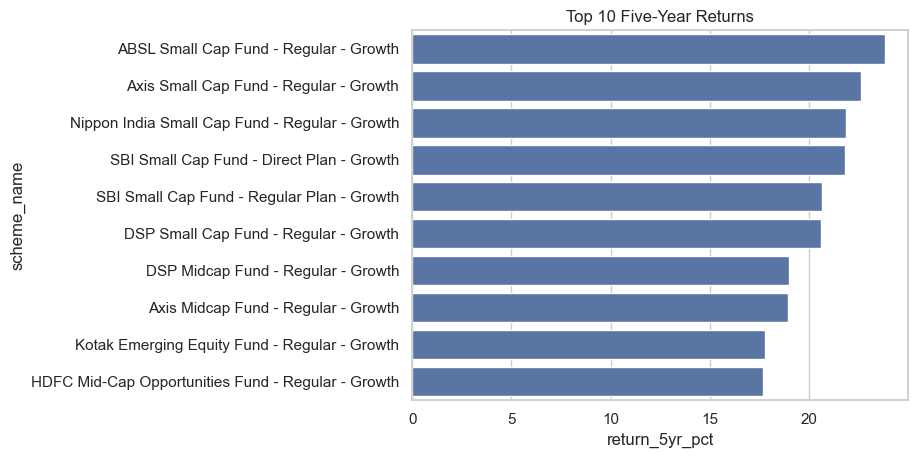

In [19]:
best = performance.nlargest(
    10,
    "return_5yr_pct"
)

sns.barplot(
    data=best,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Five-Year Returns")

plt.show()

### Insight 1
Most mutual fund schemes exhibited a positive long-term NAV trend between 2022 and 2026, indicating sustained growth in the Indian mutual fund industry.

**Chart Reference:** Daily NAV Trends (2022–2026)

### Insight 2
The highlighted 2023 period showed accelerated NAV appreciation across several schemes, consistent with a broad market bull run.

**Chart Reference:** Daily NAV Trends with Bull Run Highlight

### Insight 3
During the highlighted 2024 correction period, NAV growth moderated and several schemes experienced temporary declines before recovering.

**Chart Reference:** Daily NAV Trends with Market Correction Highlight

### Insight 4
One scheme consistently maintained substantially higher NAV values than all other schemes, suggesting a mature fund with significant historical appreciation.

**Chart Reference:** Daily NAV Trends (2022–2026)

### Insight 5
SBI Mutual Fund maintained the highest Assets Under Management (AUM) throughout 2022–2025 and crossed approximately ₹12.5 lakh crore in 2025, significantly outperforming other fund houses.

**Chart Reference:** AUM Growth by Fund House

### Insight 6
All major fund houses demonstrated continuous year-over-year AUM growth, indicating increasing investor participation and expansion of the mutual fund industry.

**Chart Reference:** AUM Growth by Fund House

### Insight 7
Monthly SIP inflows remained relatively stable between ₹11 million and ₹14 million throughout the observed period, reflecting consistent retail investment behaviour.

**Chart Reference:** Monthly SIP Inflow Time-Series

### Insight 8
The SIP time series exhibited periodic fluctuations rather than sharp declines, indicating resilient investor confidence even during market volatility.

**Chart Reference:** Monthly SIP Inflow Time-Series

### Insight 9
The highest monthly SIP inflow occurred near the end of the observed period, suggesting strengthening systematic investment participation over time.

**Chart Reference:** Monthly SIP Inflow Time-Series with Annotation

### Insight 10
Banking and Information Technology sectors dominate equity mutual fund portfolios, indicating strong preference for large-cap sectors. It covers approximately 33.2% of the total spread. It is followed by Pharma, Automobile, Utilities, FMCG, Infrastructure and diversified follow up with each above 5% and thus influencing the mutual fund portfolio.

**Chart Reference:** Sector Allocation Donut Chart